# Obtendo dados do Banco Mundial com Python
Demonstrando como python pode ser uma ferramenta poderosa na obtenção de dados públicos disponíveis via APIs. Usaremos Banco Mundial e IPEA para dados macro/esg e yahoo finance para preços.
Passaremos também pela biblioteca que estou desenvolvendo de analytics

Thales Batiston Marques


2021

In [184]:
# Importing basic packages
import pandas as pd
from pandas_datareader import wb  # import direct world bank series
import wbgapi as wbapi  # optional world bank series
from matplotlib import style
from analytics import *  # biblioteca de anayltics
import ipeadatapy as ip  # ipeadata
import statsmodels.api as sm
import numpy as np

# Plot style
style.use('ggplot')
%matplotlib inline

## Procurando as chaves
O primeiro passo a ser realizado na API do Banco Mundial é encontrar a fonte do dado, ou seja, qual país/região do dado desejado.
A primeira coluna é o código (ID) a ser procurado e a segunda é o nome completo.


No código abaixo, pegamos as 5 primeiras regiões disponíveis

In [185]:
region = wbapi.region.Series()
region.head(5)

AFE                Africa Eastern and Southern
AFR                                     Africa
AFW                 Africa Western and Central
ARB                                 Arab World
CAA    Sub-Saharan Africa (IFC classification)
Name: RegionName, dtype: object

Para países, teremos uma lista maior, mas podemos encontrar o Brasil, por exemplo. Podemos buscar pelas chaves de séries de Economies. Intecionalmente, imprimimos as 30 primeiras economias para o Brasil Aparecer

In [186]:
eco = wbapi.economy.Series()
eco.head(30)

ABW                          Aruba
AFE    Africa Eastern and Southern
AFG                    Afghanistan
AFW     Africa Western and Central
AGO                         Angola
ALB                        Albania
AND                        Andorra
ARB                     Arab World
ARE           United Arab Emirates
ARG                      Argentina
ARM                        Armenia
ASM                 American Samoa
ATG            Antigua and Barbuda
AUS                      Australia
AUT                        Austria
AZE                     Azerbaijan
BDI                        Burundi
BEL                        Belgium
BEN                          Benin
BFA                   Burkina Faso
BGD                     Bangladesh
BGR                       Bulgaria
BHR                        Bahrain
BHS                   Bahamas, The
BIH         Bosnia and Herzegovina
BLR                        Belarus
BLZ                         Belize
BMU                        Bermuda
BOL                 

Supondo que precisamos buscar qual é o código de outro país que não está nos 30 primeiros impressos na célula anterior, com apenas uma linha de comando isso é possível

In [187]:
eco[eco == 'Poland']

POL    Poland
Name: EconomyName, dtype: object

O Banco Mundial possui diversas séries disponíveis, vamos consultar se existe alguma relacionada a hospitais

In [212]:
series = wbapi.series.info(q='forest')
series

id,value
AG.LND.FRST.K2,Forest area (sq. km)
AG.LND.FRST.ZS,Forest area (% of land area)
NV.AGR.EMPL.KD,"Agriculture, forestry, and fishing, value added per worker (constant 2010 US$)"
NV.AGR.TOTL.CD,"Agriculture, forestry, and fishing, value added (current US$)"
NV.AGR.TOTL.CN,"Agriculture, forestry, and fishing, value added (current LCU)"
NV.AGR.TOTL.KD,"Agriculture, forestry, and fishing, value added (constant 2010 US$)"
NV.AGR.TOTL.KD.ZG,"Agriculture, forestry, and fishing, value added (annual % growth)"
NV.AGR.TOTL.KN,"Agriculture, forestry, and fishing, value added (constant LCU)"
NV.AGR.TOTL.ZS,"Agriculture, forestry, and fishing, value added (% of GDP)"
NY.ADJ.DFOR.CD,Adjusted savings: net forest depletion (current US$)



## Obtendo as séries
Pegaremos a série de % de área florestal

<AxesSubplot:title={'center':'Forest area (% of land area) - Brazil'}>

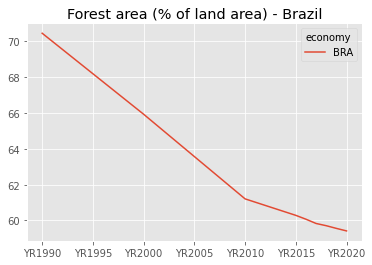

In [189]:
bra_series = wbapi.data.DataFrame(economy='BRA', series='AG.LND.FRST.ZS').T
bra_series.plot(title='Forest area (% of land area) - Brazil')

# Analytics com Python
Nessa sessão iremos utilizar dados da ITUB4 usando yahoo finance e trazendo algumas análises para o papel

Pegando a série de preços da  API do yahoo finance:

In [190]:
start_dt = '2015-01-01'
end_dt = '2021-10-11'
stock = web.DataReader('ITUB4.SA', 'yahoo', start=start_dt, end=end_dt)
stock.tail()

,High,Low,Open,Close,Volume,Adj Close
Date,,,,,,
2021-10-05,25.379999,24.340000,24.600000,24.93,49202600.0,24.93
2021-10-06,25.129999,24.360001,24.549999,25.01,39050500.0,25.01
2021-10-07,25.250000,24.400000,25.129999,24.48,38428000.0,24.48
2021-10-08,25.350000,24.629999,24.660000,24.66,48442500.0,24.66
2021-10-11,24.809999,24.219999,24.580000,24.23,42764400.0,24.23


Normalizamos a série dos preços de ajuste com os retornos cumulativos do papel. A série azul representa o retorno acumulado e a área cinza é o intervalo de dois desvio padrões.

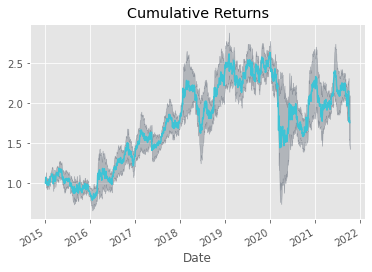

In [191]:
cum_ret_series = cum_ret(stock['Adj Close']) 

Plotamos também o Underwater para analizarmos o drawdown histórico do papel

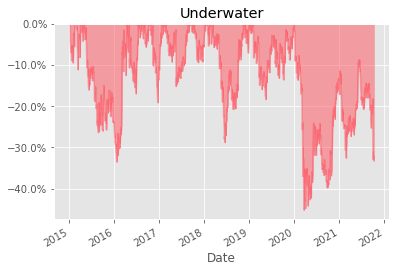

In [192]:
und = underwater(stock['Adj Close']) 

Os 5 maiores drawdowns podem ser vistos no gráfico abaixo:

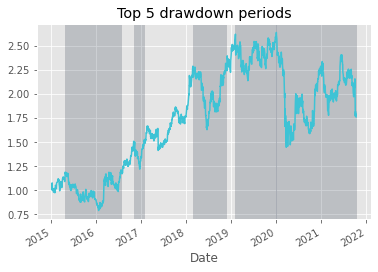

In [193]:
top = top_5_dd(stock['Adj Close']) 

In [194]:
top

,start_dt,max_dt,end_dt,dd_value,mdd_duration
0,2020-01-02 00:00:00,2020-03-23 00:00:00,2021-10-11 00:00:00,-0.45214,648 days 00:00:00
1,2015-04-24 00:00:00,2016-01-20 00:00:00,2016-07-18 00:00:00,-0.335487,451 days 00:00:00
2,2018-02-23 00:00:00,2018-06-18 00:00:00,2018-11-16 00:00:00,-0.288179,266 days 00:00:00
3,2016-10-31 00:00:00,2016-12-19 00:00:00,2017-01-23 00:00:00,-0.19179,84 days 00:00:00
4,2019-02-04 00:00:00,2019-05-16 00:00:00,2019-12-30 00:00:00,-0.184241,329 days 00:00:00


Outro gráfico de análise é o bar chat dos retornos anuais|

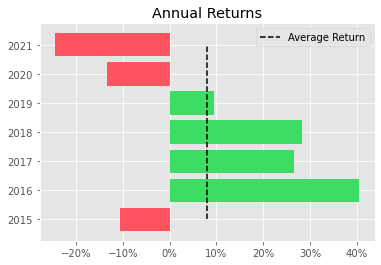

In [195]:
an_ret = annual_ret(stock['Adj Close'])

A volatilidade histórica:

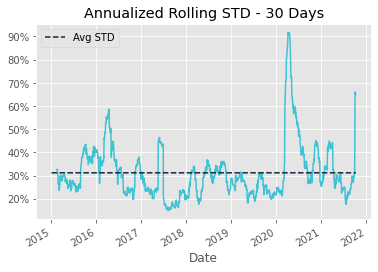

In [196]:
st = rolling_std(stock['Adj Close'])

E, para finalizar, mais alguns gráficos úteis para análise:

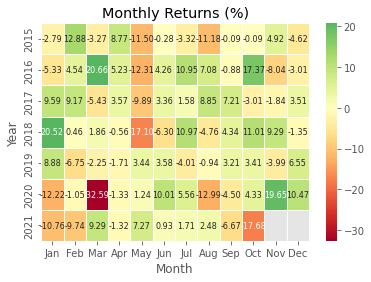

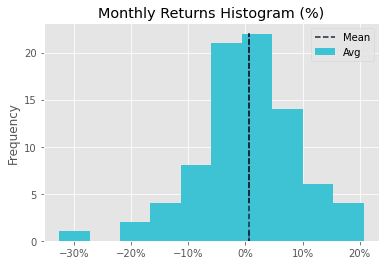

In [197]:
heat = monthly_heatmap(stock['Adj Close'])
mh = monthly_hist(stock['Adj Close'])

## Bônus: IPEA Data
Todo o banco de dados do IPEADATA está disponível para consulta via API. Abaixo alguns exemplos

In [198]:
series = ip.list_series()
igpm_codes = series[series['CODE'].str.contains('IGPM')]
igpm_codes

,CODE,NAME
4785,IGP_IGPMG,Preços - IGP-M
4814,IGP12_IGPM12,Preços - IGP-M - geral - índice (ago. 1994 = 100)
4815,IGP12_IGPMG12,Preços - IGP-M
4816,IGP12_IGPMG1D12,Preços - IGP-M - 1º decêndio
4817,IGP12_IGPMG2D12,Preços - IGP-M - 2º decêndio


In [199]:
# Getting IGPM
series_name = 'IGP12_IGPM12'
igpm_meta = ip.metadata(series_name)
igpm_values = ip.timeseries(series_name, yearGreaterThan=2010)

As consultas retornam um metadata com informações relevantes de cadastro/data de atualização da série escolhida

O output da série pode ser normalizado e assim pode ser criada uma série a partir do ponto desejado

In [200]:
igpm_meta

,CODE,NAME,COMMENT,LAST UPDATE,BIG THEME,SOURCE ACRONYM,SOURCE,SOURCE URL,FREQUENCY,MEASURE,UNIT,SERIES STATUS,THEME CODE,COUNTRY,NUMERICA
0,IGP12_IGPM12,Preços - IGP-M - geral - índice (ago. 1994 = 100),Os índices de preços medem a variação média do...,2021-09-29T12:44:00.423-03:00,Macroeconômico,FGV/Conj. Econ. - IGP,"Fundação Getulio Vargas, Conjuntura Econômica ...",www.fgv.br,Mensal,-,None,A,9,BRA,True


In [201]:
igpm_values.head()

,YEAR,DAY,MONTH,CODE,RAW DATE,VALUE (-)
DATE,,,,,,
2011-01-01,2011,1,1,IGP12_IGPM12,2011-01-01T00:00:00-02:00,453.875
2011-02-01,2011,1,2,IGP12_IGPM12,2011-02-01T00:00:00-02:00,458.397
2011-03-01,2011,1,3,IGP12_IGPM12,2011-03-01T00:00:00-03:00,461.249
2011-04-01,2011,1,4,IGP12_IGPM12,2011-04-01T00:00:00-03:00,463.311
2011-05-01,2011,1,5,IGP12_IGPM12,2011-05-01T00:00:00-03:00,465.311


In [202]:
# Reordering values
igpm_values.rename(columns={'VALUE (-)': 'value'}, inplace=True)
igpm_values['value'] = np.log(1 + igpm_values['value'].pct_change())
igpm_values['cumulative'] = np.exp(igpm_values['value'].cumsum())
# 12 Month IGPM
igpm_values['cumulative_12m'] = igpm_values['cumulative'] / igpm_values['cumulative'].shift(12)

# Yearly IGPM
igpm_year = igpm_values.groupby(by=['YEAR'], as_index=False)['value'].sum()
igpm_year['cumulative'] = np.exp(igpm_year['value']) - 1
igpm_year.set_index('YEAR', inplace=True)

Após o tratamento dos dados, o IGPM mensal para o intervalo de 2012 fica com o seguinte comportamento

<AxesSubplot:xlabel='DATE'>

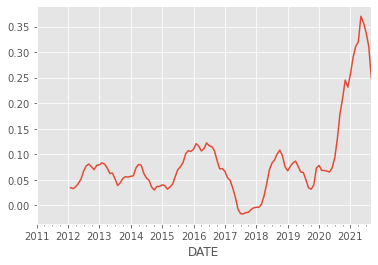

In [203]:
igpm_values['cumulative_12m'].sub(1).plot()

Conversões rápidas podem ser feitas para visualizarmos o IGPM anual

<AxesSubplot:xlabel='YEAR'>

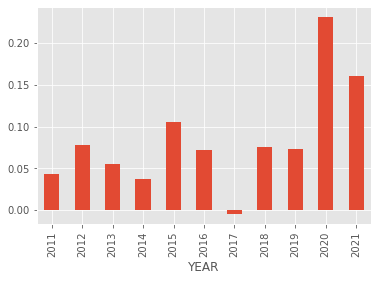

In [204]:
igpm_year['cumulative'].plot.bar()

Do ponto de vista de mapa de calor também podemos ver alguns insights

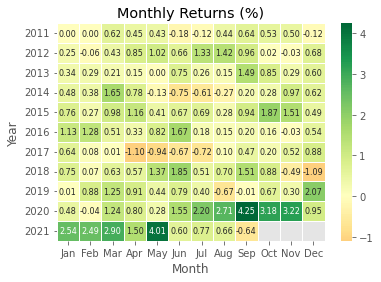

In [205]:
igpm_values.index.name = 'Date'
igmp_heatmap = monthly_heatmap(igpm_values['cumulative'])

Diversos dados macroeconômicos e setoriais podem ser encontrados na api. Por exemplo, a Variação real do Pib da Construção Civil

<AxesSubplot:xlabel='DATE'>

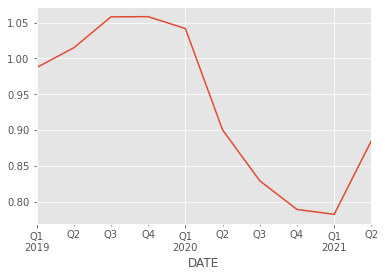

In [206]:
# Construcao Civil GDP
gdp_rs = ip.timeseries('SCN104_PIBICCG104', yearGreaterThan=2018)
gdp_rs.rename(columns={'VALUE ((%))': 'value'}, inplace=True)
gdp_rs['value'] = gdp_rs['value'] / 100
gdp_rs['cumulative'] = (1 + gdp_rs['value']).cumprod()
gdp_rs['cumulative'].plot()

Por último, o número de horas voadas vs número de passageiros

<AxesSubplot:title={'center':'Scatter Plot - Quantidade de Passageiros vs Quantidade de Voos'}, xlabel='voos_qty', ylabel='pax_qty'>

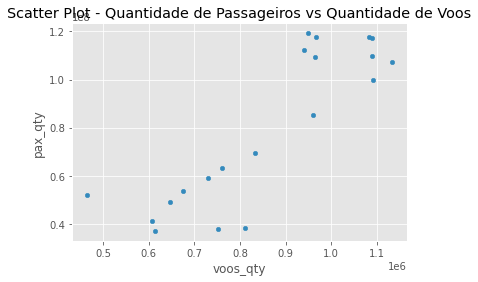

In [210]:
voos = ip.timeseries('ANAC_ER', yearGreaterThan=2000)
pax = ip.timeseries('ANAC_PAX', yearGreaterThan=2000)
comp_v = pd.DataFrame(index=voos.index, columns=['voos_qty', 'pax_qty'])
comp_v['voos_qty'] = voos['VALUE (Unidade)']
comp_v['pax_qty'] = pax['VALUE (Pessoa)']

comp_v.plot.scatter('voos_qty', 'pax_qty', title='Scatter Plot - Quantidade de Passageiros vs Quantidade de Voos')

Uma regressão linear simples pode ser feita com esses dados

In [218]:
pax_reg = comp_v['pax_qty'].values
comp_v_reg = comp_v['voos_qty'].values
comp_v_reg = sm.add_constant(comp_v_reg)

reg = sm.OLS(pax_reg, comp_v_reg)
results = reg.fit()
results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.740
Model:                            OLS   Adj. R-squared:                  0.725
Method:                 Least Squares   F-statistic:                     51.21
Date:                Thu, 14 Oct 2021   Prob (F-statistic):           1.15e-06
Time:                        16:02:32   Log-Likelihood:                -360.23
No. Observations:                  20   AIC:                             724.5
Df Residuals:                      18   BIC:                             726.4
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       -4.18e+07   1.74e+07     -2.400      0.027   -7.84e+07   -5.21e+06
x1           141.7368     19.805      7.156      0.000     100.127     183.346
==============================================================================
Omnibus:                        0.074   Durbin-Watson:                   0.146
Prob(Omnibus):                  0.964   Jarque-Bera (JB):                0.064
Skew:                          -0.037   Prob(JB):                        0.968
Kurtosis:                       2.732   Cond. No.                     4.04e+06
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 4.04e+06. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

### Próximos passos
Os gráficos apresentados podem ser usados tanto no nível do single names como no nível do portfólio. Essas ferramentas podem levar uma visão mais de análise de portfólio dentro de um fundo de equities